In [17]:
import numpy as np 
import matplotlib.pyplot as  plt
import pandas as pd 

In [18]:
df=pd.read_csv("price_data.csv")

In [19]:
df.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               249 non-null    object
 1   avg_monthly_price  249 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.0+ KB


,date,avg_monthly_price
0,2005-01-01,5500
1,2005-02-01,5476
2,2005-03-01,5466
3,2005-04-01,5487
4,2005-05-01,5876


In [21]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [22]:
df

,avg_monthly_price
date,
2005-01-01,5500
2005-02-01,5476
2005-03-01,5466
2005-04-01,5487
2005-05-01,5876
...,...
2025-05-01,14263
2025-06-01,14263
2025-07-01,16000


In [23]:
print("Basic Statistics:")
print(df.describe())

Basic Statistics:
       avg_monthly_price
count         249.000000
mean         7918.891566
std          2804.992684
min          3500.000000
25%          6123.000000
50%          7250.000000
75%          9783.000000
max         16163.000000


In [24]:
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
avg_monthly_price    0
dtype: int64


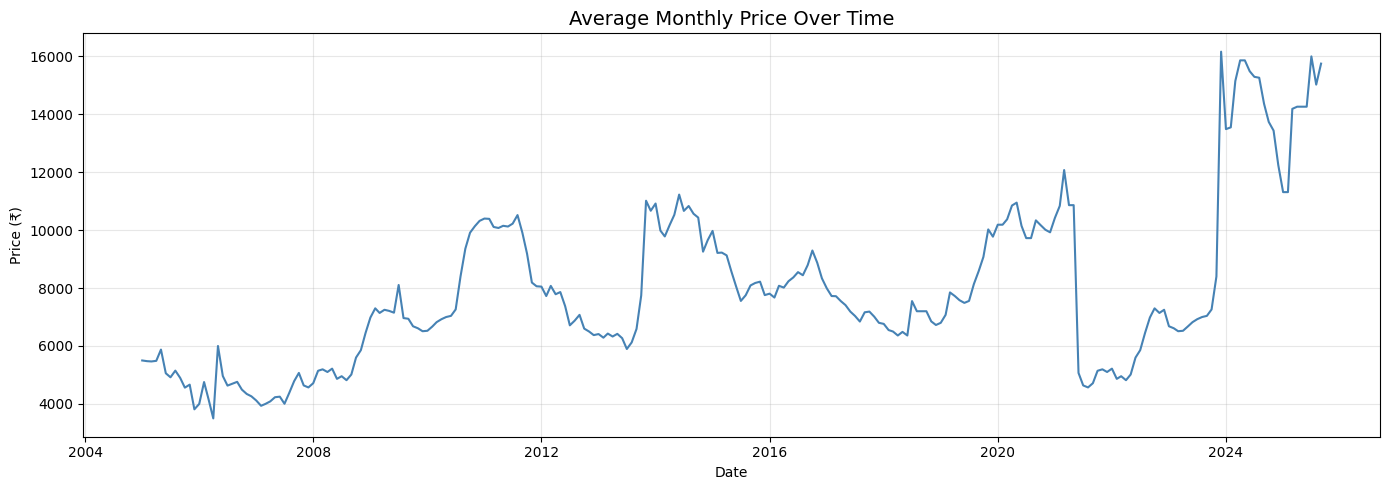

In [26]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['avg_monthly_price'], color='steelblue', linewidth=1.5)
plt.title('Average Monthly Price Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
df['year'] = df.index.year
df['month'] = df.index.month
df

,avg_monthly_price,year,month
date,,,
2005-01-01,5500,2005,1
2005-02-01,5476,2005,2
2005-03-01,5466,2005,3
2005-04-01,5487,2005,4
2005-05-01,5876,2005,5
...,...,...,...
2025-05-01,14263,2025,5
2025-06-01,14263,2025,6
2025-07-01,16000,2025,7


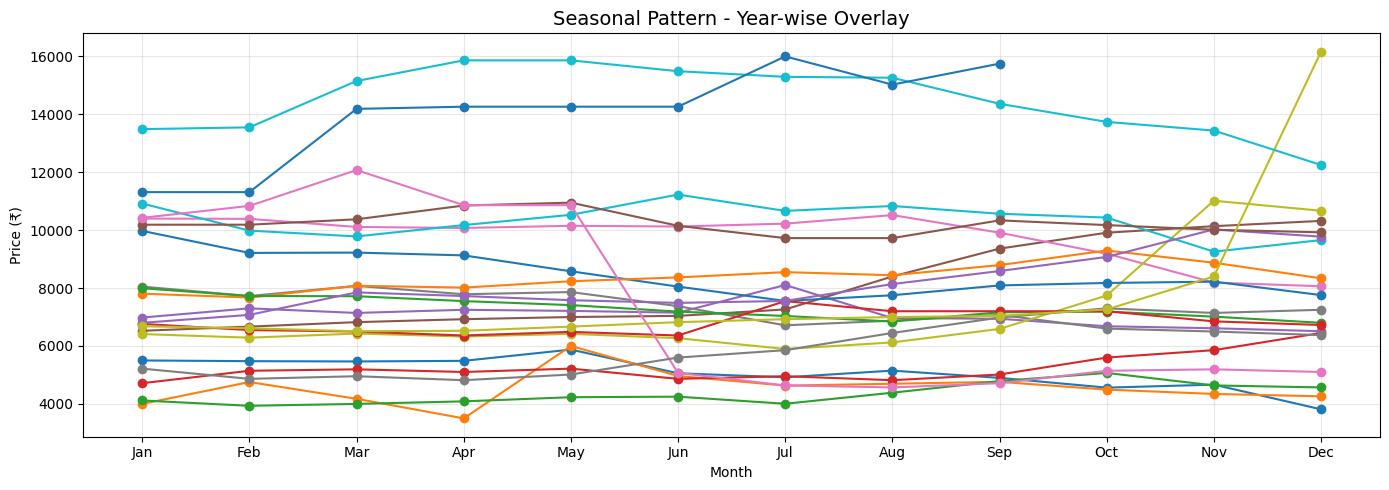

In [32]:
plt.figure(figsize=(14, 5))
for year, group in df.groupby('year'):
    plt.plot(group['month'], group['avg_monthly_price'], marker='o', label=str(year))
plt.title('Seasonal Pattern - Year-wise Overlay', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Price (₹)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1400x500 with 0 Axes>

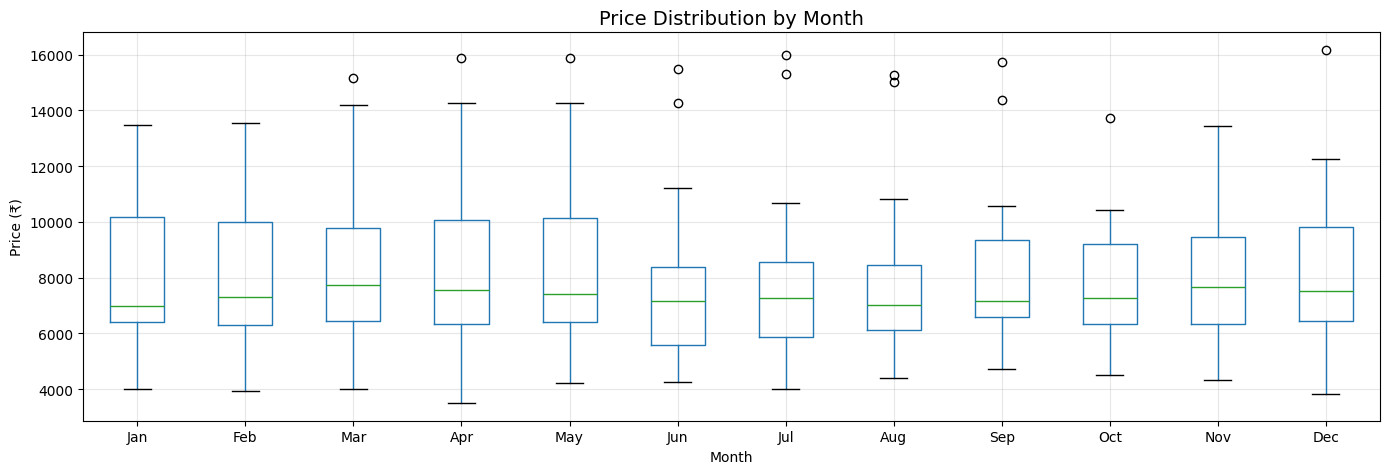

In [33]:
plt.figure(figsize=(14, 5))
df.boxplot(column='avg_monthly_price', by='month', figsize=(14, 5))
plt.title('Price Distribution by Month', fontsize=14)
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('Price (₹)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

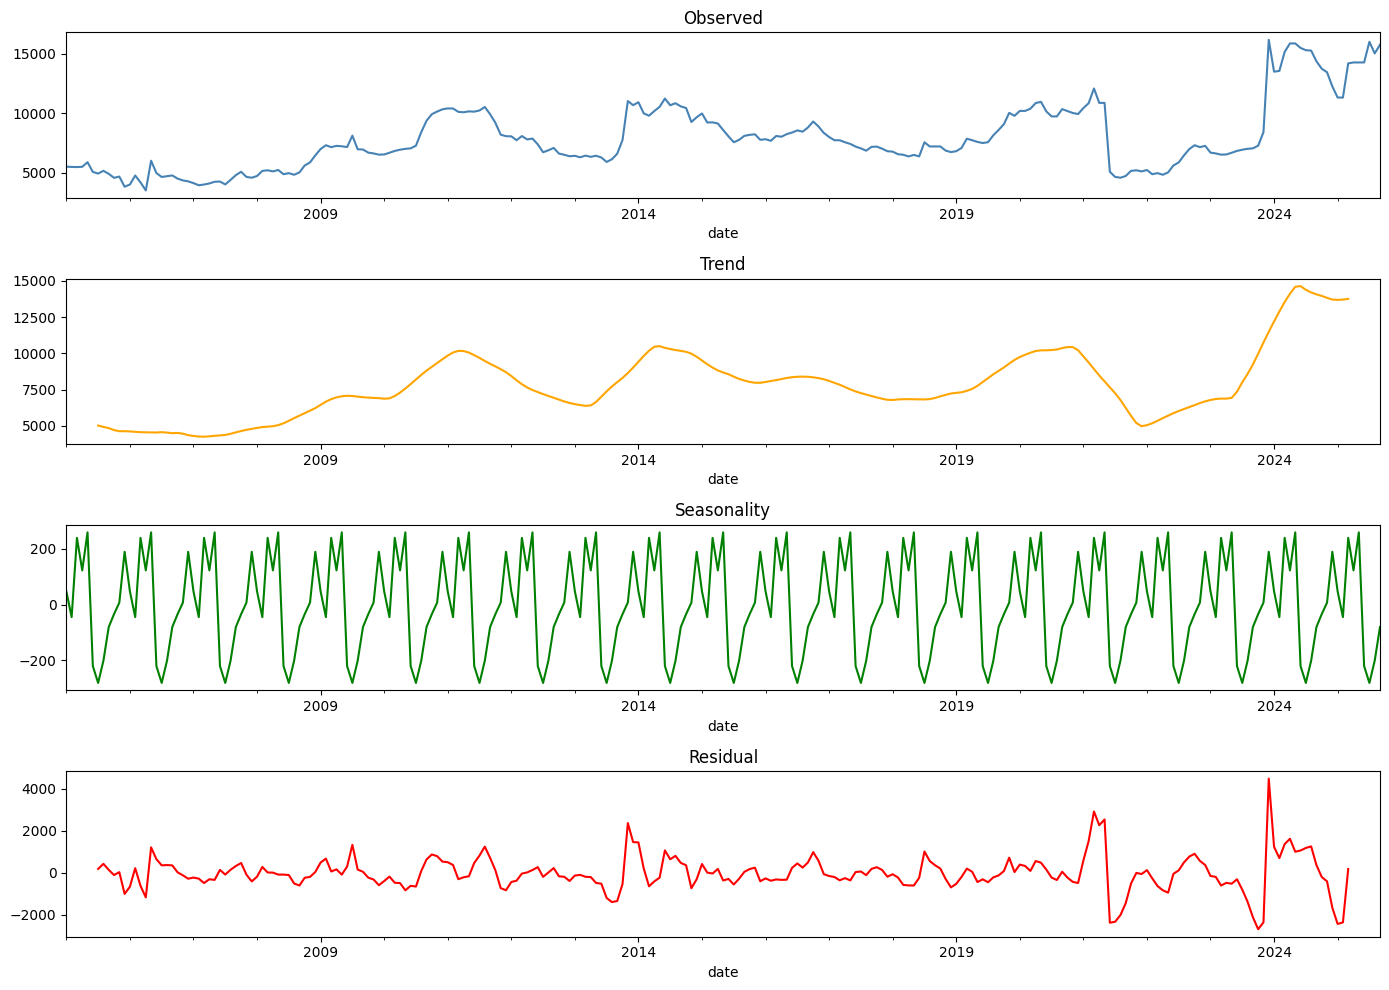

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['avg_monthly_price'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed', color='steelblue')
decomposition.trend.plot(ax=axes[1], title='Trend', color='orange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality', color='green')
decomposition.resid.plot(ax=axes[3], title='Residual', color='red')
plt.tight_layout()
plt.show()



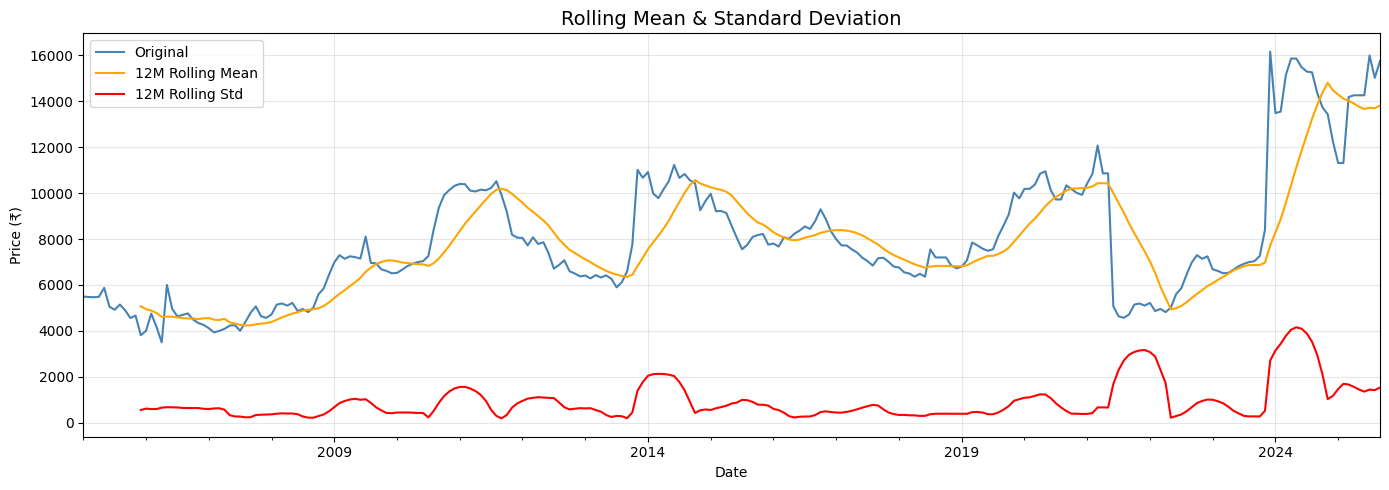

In [36]:
# Rolling Mean & Std 
plt.figure(figsize=(14, 5))
df['avg_monthly_price'].plot(label='Original', color='steelblue')
df['avg_monthly_price'].rolling(window=12).mean().plot(label='12M Rolling Mean', color='orange')
df['avg_monthly_price'].rolling(window=12).std().plot(label='12M Rolling Std', color='red')
plt.title('Rolling Mean & Standard Deviation', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [37]:
df.drop(columns=['year', 'month'], inplace=True)

Total expected months: 249
Total actual months  : 249
Missing months       : 0


In [ ]:
profile = ProfileReport(df, title="Data Profiling Report", explorative=True)
profile.to_file("report.html")